NEURAL NETWORK EXPERIMENT - XOR

PERCEPTRON
AND: [0, 0, 0, 1]
OR : [0, 1, 1, 1]
XOR: [1, 1, 0, 0] -> FAILS

2-LAYER NN
XOR: [[0]
 [1]
 [1]
 [1]] -> SUCCESS


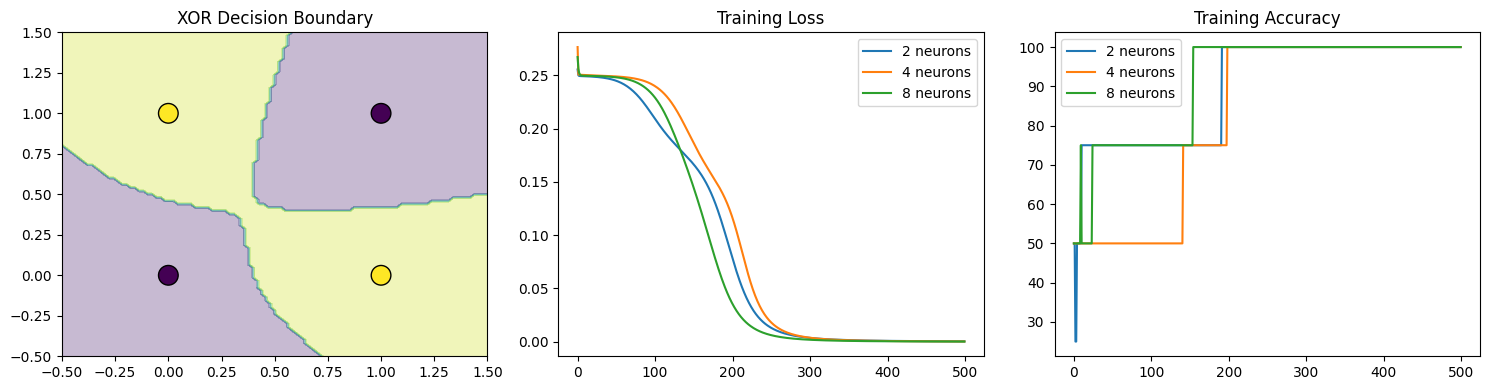

IN-LAB: NEURAL NETWORK (PROBLEM WISE)

PROBLEM 1: PERCEPTRON
AND : [0, 0, 0, 1]
OR  : [0, 1, 1, 1]
XOR : [1, 1, 0, 0] -> FAILS

PROBLEM 2: 2-LAYER NN (XOR)
XOR : [[0]
 [1]
 [1]
 [0]] -> SUCCESS

PROBLEM 3: ARCHITECTURE COMPARISON
2 neurons -> Accuracy: 75%
4 neurons -> Accuracy: 100%
8 neurons -> Accuracy: 100%

SUMMARY
* Perceptron fails for XOR
* Multi-layer NN solves XOR
* More neurons -> better learning


In [5]:
# Post-Lab


import numpy as np
import matplotlib.pyplot as plt

# ================= PART A: PERCEPTRON =================
class Perceptron:
    def __init__(self):
        self.w = [0,0]
        self.b = 0

    def train(self,X,y,ep=20):
        for _ in range(ep):
            for i in range(len(X)):
                p = 1 if X[i][0]*self.w[0] + X[i][1]*self.w[1] + self.b >= 0 else 0
                e = y[i] - p
                self.w[0] += e*X[i][0]
                self.w[1] += e*X[i][1]
                self.b += e

    def pred(self,X):
        return [1 if x[0]*self.w[0] + x[1]*self.w[1] + self.b >= 0 else 0 for x in X]


# ================= PART B: 2-LAYER NN =================
class NN:
    def __init__(self):
        self.W1 = np.random.randn(2,3)
        self.W2 = np.random.randn(3,1)

    def sig(self,x):
        return 1/(1+np.exp(-x))

    def train(self,X,y,ep=3000):
        y = np.array(y).reshape(-1,1)
        for _ in range(ep):
            h = self.sig(X @ self.W1)
            o = self.sig(h @ self.W2)

            e = o - y
            d2 = e
            d1 = d2 @ self.W2.T * h*(1-h)

            self.W2 -= 0.5 * h.T @ d2
            self.W1 -= 0.5 * X.T @ d1

    def pred(self,X):
        h = self.sig(X @ self.W1)
        o = self.sig(h @ self.W2)
        return (o > 0.5).astype(int)


# ================= PART C: MODEL FOR GRAPHS =================
class Model:
    def __init__(self, h):
        self.W1 = np.random.randn(2, h) * 0.5
        self.b1 = np.zeros(h)
        self.W2 = np.random.randn(h, 1) * 0.5
        self.b2 = np.zeros(1)
        self.loss = []
        self.acc = []

    def sig(self, x):
        return 1/(1+np.exp(-x))

    def train(self, X, y, ep=500):
        y = y.reshape(-1,1)
        for _ in range(ep):
            h = self.sig(X @ self.W1 + self.b1)
            o = self.sig(h @ self.W2 + self.b2)

            self.loss.append(np.mean((y - o)**2))
            self.acc.append(np.mean((o > 0.5) == y) * 100)

            d2 = o - y
            d1 = d2 @ self.W2.T * h*(1-h)

            self.W2 -= 0.5 * h.T @ d2
            self.b2 -= 0.5 * np.sum(d2, axis=0)
            self.W1 -= 0.5 * X.T @ d1
            self.b1 -= 0.5 * np.sum(d1, axis=0)

    def predict(self, X):
        h = self.sig(X @ self.W1 + self.b1)
        o = self.sig(h @ self.W2 + self.b2)
        return (o > 0.5).astype(int)


# ================= MAIN =================
print("="*50)
print("NEURAL NETWORK EXPERIMENT - XOR")
print("="*50)

X = np.array([[0,0],[0,1],[1,0],[1,1]])

y_and = [0,0,0,1]
y_or  = [0,1,1,1]
y_xor = np.array([0,1,1,0])

# -------- PART A --------
print("\nPERCEPTRON")
p = Perceptron()

p.train(X,y_and)
print("AND:", p.pred(X))

p.train(X,y_or)
print("OR :", p.pred(X))

p.train(X,y_xor)
print("XOR:", p.pred(X), "-> FAILS")

# -------- PART B --------
print("\n2-LAYER NN")
nn = NN()
nn.train(X,y_xor)
print("XOR:", nn.pred(X), "-> SUCCESS")

# -------- PART C --------
models = {}
for n in [2,4,8]:
    m = Model(n)
    m.train(X,y_xor)
    models[n] = m

# ===== DECISION BOUNDARY =====
model_viz = Model(4)
model_viz.train(X,y_xor)

xx, yy = np.meshgrid(np.linspace(-0.5,1.5,100),
                     np.linspace(-0.5,1.5,100))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_viz.predict(grid).reshape(xx.shape)

# ===== PLOTS =====
plt.figure(figsize=(15,4))

# 1. Decision Boundary
plt.subplot(1,3,1)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y_xor, s=200, edgecolor='black')
plt.title("XOR Decision Boundary")

# 2. Loss
plt.subplot(1,3,2)
for n in models:
    plt.plot(models[n].loss, label=f"{n} neurons")
plt.title("Training Loss")
plt.legend()

# 3. Accuracy
plt.subplot(1,3,3)
for n in models:
    plt.plot(models[n].acc, label=f"{n} neurons")
plt.title("Training Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# In-Lab


import numpy as np

print("="*60)
print("IN-LAB: NEURAL NETWORK (PROBLEM WISE)")
print("="*60)

# ================= PROBLEM 1: PERCEPTRON =================
class Perceptron:
    def __init__(self):
        self.w = [0,0]
        self.b = 0

    def train(self,X,y):
        for _ in range(20):
            for i in range(len(X)):
                p = 1 if X[i][0]*self.w[0] + X[i][1]*self.w[1] + self.b >= 0 else 0
                e = y[i] - p
                self.w[0] += e*X[i][0]
                self.w[1] += e*X[i][1]
                self.b += e

    def pred(self,X):
        return [1 if x[0]*self.w[0] + x[1]*self.w[1] + self.b >= 0 else 0 for x in X]


# ================= PROBLEM 2: 2-LAYER NN =================
class NN:
    def __init__(self):
        self.W1 = np.random.randn(2,3)
        self.W2 = np.random.randn(3,1)

    def sig(self,x):
        return 1/(1+np.exp(-x))

    def train(self,X,y):
        y = np.array(y).reshape(-1,1)
        for _ in range(3000):
            h = self.sig(X @ self.W1)
            o = self.sig(h @ self.W2)

            d2 = o - y
            d1 = d2 @ self.W2.T * h*(1-h)

            self.W2 -= 0.5 * h.T @ d2
            self.W1 -= 0.5 * X.T @ d1

    def pred(self,X):
        h = self.sig(X @ self.W1)
        o = self.sig(h @ self.W2)
        return (o > 0.5).astype(int)


# ================= PROBLEM 3: DIFFERENT ARCHITECTURES =================
class Model:
    def __init__(self,h):
        self.W1 = np.random.randn(2,h)
        self.W2 = np.random.randn(h,1)

    def sig(self,x):
        return 1/(1+np.exp(-x))

    def train(self,X,y):
        y = np.array(y).reshape(-1,1)
        for _ in range(1000):
            h = self.sig(X @ self.W1)
            o = self.sig(h @ self.W2)

            d2 = o - y
            d1 = d2 @ self.W2.T * h*(1-h)

            self.W2 -= 0.5 * h.T @ d2
            self.W1 -= 0.5 * X.T @ d1

    def pred(self,X):
        return (self.sig(self.sig(X @ self.W1) @ self.W2) > 0.5).astype(int)


# ================= MAIN =================
X = np.array([[0,0],[0,1],[1,0],[1,1]])

print("\nPROBLEM 1: PERCEPTRON")
p = Perceptron()

p.train(X,[0,0,0,1])
print("AND :", p.pred(X))

p.train(X,[0,1,1,1])
print("OR  :", p.pred(X))

p.train(X,[0,1,1,0])
print("XOR :", p.pred(X), "-> FAILS")

print("\nPROBLEM 2: 2-LAYER NN (XOR)")
nn = NN()
nn.train(X,[0,1,1,0])
print("XOR :", nn.pred(X), "-> SUCCESS")

print("\nPROBLEM 3: ARCHITECTURE COMPARISON")
for n in [2,4,8]:
    m = Model(n)
    m.train(X,[0,1,1,0])
    acc = np.mean(m.pred(X).flatten() == [0,1,1,0]) * 100
    print(f"{n} neurons -> Accuracy: {acc:.0f}%")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("* Perceptron fails for XOR")
print("* Multi-layer NN solves XOR")
print("* More neurons -> better learning")